# Shapley Values for XGBoost Model
1. Create Initial Model

In [1]:
# importing packages
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score


c:\Users\cscur\miniconda3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

file_path = "C:/Users/cscur/OneDrive/STATSM148/statM148proj-main/truncated_data_codex.parquet"

df_simple = (
    pl.scan_parquet(file_path)
    .drop(['id', 'cutoff_time',
            'journey_terminal_time',
         'journey_terminal_reason'])
    .drop_nulls()  # Polars equivalent of .dropna()
    .collect()     # This triggers the actual calculation
)

#cols = df_simple.columns
#words = ['seen', 'count', 'cutoff']
#df_simple = df_simple.drop([col for col in cols if any(w in col for w in words)])

# 1. Prepare Features and Target
# one-hot encode 'last_stage' cat variable
categorical = [col for col, dtype in zip(df_simple.columns, df_simple.dtypes)
            if dtype == pl.Utf8 or dtype == pl.Categorical]
df_ml = df_simple.to_dummies(categorical)#.drop(['first_event_name', 'last_event_name'])

# Define target (y) and features (X)
y = df_ml["label_order_shipped"].to_numpy() # TARGET: Label_order_shipped 

X = df_ml.drop(["label_order_shipped",'first_stage_Downpayment',
                'first_stage_Order Shipped', 'last_stage_Order Shipped',
                'last_event_name_order_shipped',
                'first_event_name_order_shipped']) # FEATURES: all other cols

feature_names = X.columns

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10, stratify=y
)

X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

#print(X_train.columns)
weights = X_train['sampling_weight_days'] 
X_train = X_train.drop(columns = ['sampling_weight_days'])
X_test = X_test.drop(columns = ['sampling_weight_days'])
feature_names = feature_names.remove('sampling_weight_days')

y_train = pd.Series(y_train)
y_test = pd.Series(y_test)

In [3]:
print(feature_names)

None


First we fit a model with all features included before determining which are of great or little importance to predictions. We are using an XGBoost Model due to the size of the dataset, the presence of numeric and categorical features, as well as sparse features that contain many zeros (such as those that track whether or not a particular event occurs in a particular journey).

XGBoost has lots of possible hyperparameters that control the model's behaviour. The values are selected based on what we know about the data. The model is fitted to the training data with the testing data as a benchmark. We then predict the probability of success for the testing data and compare it to the true outcomes. In this case, any probability above 0.9 is labelled as a successful journey, and below 0.9 is unsuccessful.

In [4]:
model = xgb.XGBClassifier(
    objective="binary:logistic",  # outputs probabilities
    n_estimators=800,
    max_depth=8, #Higher means more complex model
    min_child_weight = 5, #How much it takes to form a new tree
    gamma = 0.5, #Similar to child_weight 
    learning_rate=0.01, #Complexity, lower = more acc and slower
    subsample=0.8, #How much of the data is used for the first tree
    colsample_bytree=0.8, #How much features are used in the beginning
    # regularization
    reg_lambda = 5,  #stabilizes model
    reg_alpha = 1, #Higher = more sparse
    random_state=42,
    early_stopping_rounds = 25
)

#print(xgb.__version__)

model.fit(X_train, y_train,
          eval_set = [(X_test, y_test)],
          verbose = False,
          sample_weight = weights)

probability = model.predict_proba(X_test)[:,1]
y_pred = (probability >= 0.9).astype(int)

Checking Accuracy

In [5]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.8499183806725432


This model predicted the correct outcome 85% of the time, so we investigate the individual features to improve this score.

Plotting Initial Feature Importance

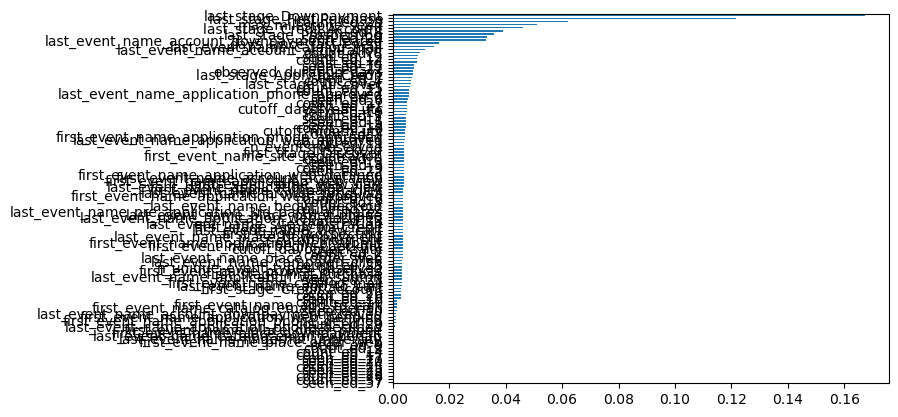

last_stage_Downpayment       0.167441
last_stage_First Purchase    0.121469
count_ed_29                  0.062159
max_milestone_seen           0.051164
last_stage_Credit Account    0.046083
                               ...   
seen_ed_25                   0.000000
seen_ed_28                   0.000000
count_ed_28                  0.000000
count_ed_37                  0.000000
seen_ed_37                   0.000000
Length: 119, dtype: float32


In [6]:
names = model.get_booster().feature_names
importance = pd.Series(model.feature_importances_, index = names)
importance = importance.sort_values(ascending = False)

importance.plot(kind = 'barh')
plt.gca().invert_yaxis()
plt.show()
print(importance)

The initial feature importance plot is difficult to read as there are 119 features present in this model. To remove unnessecary noise we remove any features with less than 0.005 importance.

Removing Features with 0 importance

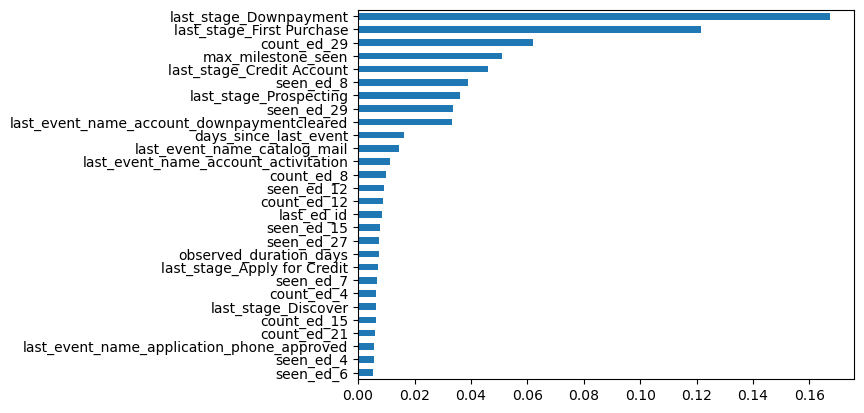

In [7]:
useless = importance[importance <= 0.005].index
importance_useful = importance.drop(useless)
importance_useful.plot(kind = 'barh')
plt.gca().invert_yaxis()
plt.show()


This plot is much clearer and shows us that last_stage_Downpayment is by far the most important feature in this model, followed by last_stage_First Purchase, and count_ed_29. The majority of the other features counting if and how often a particular feature appeared are ranked ery low, so it is interesting that evend 29 is so important. This code corresponds to account activation.  

Refitting Without Useless Features

In [8]:

X_train_u = X_train.loc[:, ~X_train.columns.isin(useless)]
X_test_u = X_test.loc[:, ~X_test.columns.isin(useless)]
useful_feature_names = X_train_u.columns


In [9]:
model_u = xgb.XGBClassifier(
    objective="binary:logistic",  # outputs probabilities
    n_estimators=800,
    max_depth=8, #Higher means more complex model
    min_child_weight = 5, #How much it takes to form a new tree
    gamma = 0.5, #Similar to child_weight 
    learning_rate=0.01, #Complexity, lower = more acc and slower
    subsample=0.8, #How much of the data is used for the first tree
    colsample_bytree=0.8, #How much features are used in the beginning
    # regularization
    reg_lambda = 5,  #stabilizes model
    reg_alpha = 1, #Higher = more sparse
    random_state=42,
    early_stopping_rounds = 25
)

#print(xgb.__version__)

model_u.fit(X_train_u, y_train,
          eval_set = [(X_test_u, y_test)],
          verbose = False,
          sample_weight = weights)

probability_u = model_u.predict_proba(X_test_u)[:,1]
y_pred_u = (probability_u >= 0.9).astype(int)

print(accuracy_score(y_test, y_pred_u))

0.8497007291326586


We can also calculate the contribution of each feature using their Shapley values.

2. Calculating Shapley Values

In [ ]:
shapley = shap.Explainer(model)
shap_values = shapley(X_test) 
# Calculates a value for each observation of each feature

shap_mean = np.abs(shap_values.values).mean(axis = 0) # collapses to mean for each feature
shap_rank = pd.Series(shap_mean, index = names).sort_values(ascending = False)
shap_rank

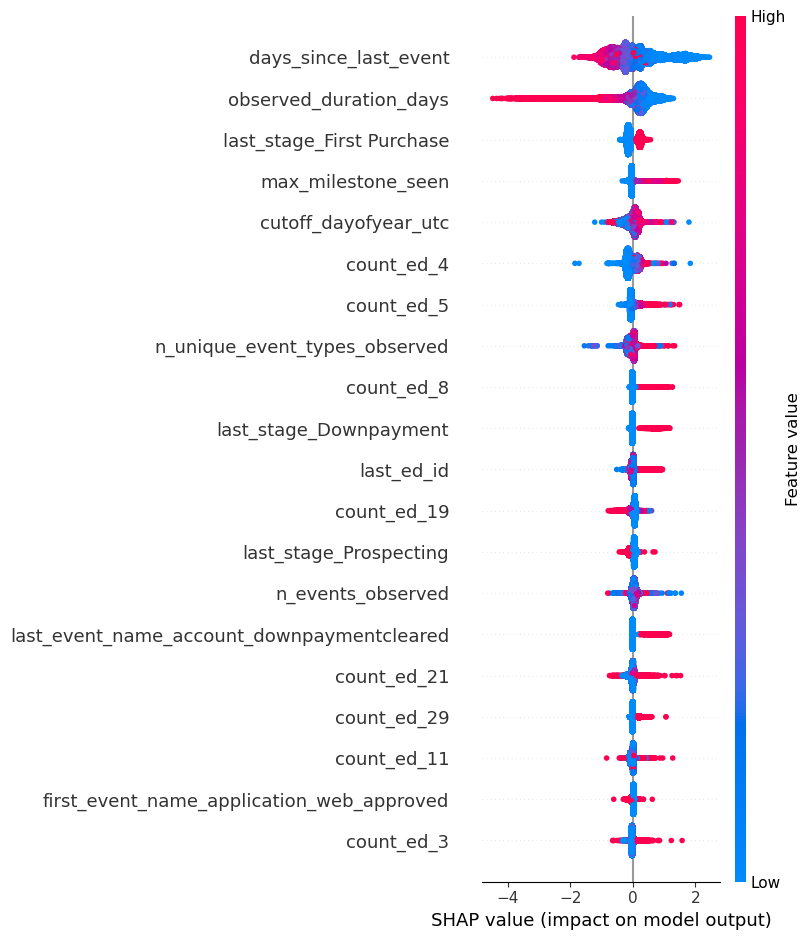

In [ ]:
shap.summary_plot(shap_values, X_test)

Interestingly, the 2 most important features from the importane plot are not even in the top 9 using this metric. The most important features are days_since_last_event, and observed_duration_days, which indicates that the timing and length of the journeys is more important than the other features and that we should focus on those in future models.

We can drop features with a low value, less than 0.01, and refit the model to see if there is an improvement.

Dropping Useless Features

In [ ]:
shap_useless = shap_rank[shap_rank <= 0.01].index
shap_useful = shap_rank.drop(shap_useless)
shap_names = shap_useful.index


In [ ]:
X_train_shap = X_train.loc[:, ~X_train.columns.isin(shap_useless)]
X_test_shap = X_test.loc[:, ~X_test.columns.isin(shap_useless)]
shap_feature_names = X_train_shap.columns

model_shap = xgb.XGBClassifier(
    objective="binary:logistic",  # outputs probabilities
    n_estimators=800,
    max_depth=8, #Higher means more complex model
    min_child_weight = 5, #How much it takes to form a new tree
    gamma = 0.5, #Similar to child_weight 
    learning_rate=0.01, #Complexity, lower = more acc and slower
    subsample=0.8, #How much of the data is used for the first tree
    colsample_bytree=0.8, #How much features are used in the beginning
    # regularization
    reg_lambda = 5,  #stabilizes model
    reg_alpha = 1, #Higher = more sparse
    random_state=42,
    early_stopping_rounds = 25
)

#print(xgb.__version__)

model_shap.fit(X_train_shap, y_train,
          eval_set = [(X_test_shap, y_test)],
          verbose = False,
          sample_weight = weights)

probability_shap = model_shap.predict_proba(X_test_shap)[:,1]
y_pred_shap = (probability_shap >= 0.9).astype(int)

print(accuracy_score(y_test, y_pred_shap))

0.849907498095549


This leads to a much simpler value that increases the accuracy ever so slightly. Notably, this model predicts the outcomes of the open journeys more accurately than any other model we have run, including the model predicting all unsuccesful journeys.

Varying the boundary for positive value

In [ ]:
probs = [0.3, 0.5, 0.7, 0.8, 0.85, 
         0.9, 0.95, 0.975, 0.99]
acc_scores = pd.Series(index = probs, dtype = float)
for p in probs:
    y_pred_shap = (probability_shap >= p).astype(int)
    acc_scores[p] = (accuracy_score(y_test, y_pred_shap))

print(acc_scores)

0.300    0.892632
0.500    0.885124
0.700    0.877821
0.800    0.869877
0.850    0.862237
0.900    0.849907
0.950    0.813951
0.975    0.784122
0.990    0.766079
dtype: float64


Using New Model Based on Shapley Values to Predict Test Data

In [ ]:
test_path = "C:/Users/cscur/OneDrive/STATSM148/statM148proj-main/truncated_test_data.parquet"
test_data = (
    pl.scan_parquet(test_path)
    .drop(['id', 'cutoff_time',
            'journey_terminal_time',
         'journey_terminal_reason'])
     # Polars equivalent of .dropna()
    .collect()     # This triggers the actual calculation
)

# 1. Prepare Features and Target
# one-hot encode 'last_stage' cat variable
categorical = [col for col, dtype in zip(test_data.columns, test_data.dtypes)
            if dtype == pl.Utf8 or dtype == pl.Categorical]
df_ml_test = test_data.to_dummies(categorical)#.drop(['first_event_name', 'last_event_name'])

# Define target (y) and features (X)
y_TEST = df_ml_test["label_order_shipped"].to_numpy() # TARGET: Label_order_shipped 

X_TEST = df_ml_test.drop(["label_order_shipped",'last_stage_null', 'first_stage_null', 'first_event_name_null', 'last_event_name_null']) # FEATURES: all other cols
feats = X_TEST.columns

#print(X_train.columns)
X_TEST = pd.DataFrame(X_TEST, columns = feats)

weights_test = X_TEST['sampling_weight_days'] 
X_TEST= X_TEST.drop(columns = ['sampling_weight_days'])

y_TEST = pd.Series(y_TEST)




In [ ]:
X_TEST_shap = X_TEST.loc[:, ~X_TEST.columns.isin(shap_useless)]
probability_test = model_shap.predict_proba(X_TEST_shap)[:,1]

y_pred_true = (probability_test >= 0.95).astype(int)

In [ ]:
ids =pl.scan_parquet(test_path).select(['id']).collect()
pred_matrix = np.column_stack((ids, probability_test))
pred_df = pd.DataFrame(pred_matrix, columns = ['id','order_shipped'])
pred_df.to_csv('submission_p.csv', index = False)

# Summary Statistics for Task 3

Because we are using an xgboost model, we cannot calculate OOB accuracy as there is no independent unused data. Instead we can calculate the cross validation.

In [ ]:
from sklearn.metrics import roc_auc_score, log_loss, average_precision_score, confusion_matrix

auc = roc_auc_score(y_test, y_pred_shap)
log = log_loss(y_test, y_pred_shap)
prec = average_precision_score(y_test, y_pred_shap)
conf = confusion_matrix(y_test, y_pred_shap)
print(auc, log, prec, conf)

0.5000465181188073 8.431367173784668 0.23401402872863644 [[70393     0]
 [21495     2]]


1. ROC AUC: 0.5
2. Log Loss: 8.43
3. Average Precision Score: 0.23
4. Confusion Matrix
    True Negatives: 70393
    False Positives: 0
    False Negatives: 21495
    True Positives: 2

# CP Profiles for Accurately Predicted Successes

In [ ]:
success = y_pred_shap[y_pred_shap == 1]
print(success)
#reference_profile = pl.DataFrame([X_test[15]], schema=list(feature_names))

NameError: name 'y_pred_shap' is not defined